In [1]:
# ==============================
# PRICE COMPARISON TOOL
# ==============================

# Core Libraries
import time
import pandas as pd
import numpy as np

# Web Scraping
import undetected_chromedriver as uc
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.keys import Keys
from selenium.common.exceptions import NoSuchElementException
from bs4 import BeautifulSoup

# Visualization
import matplotlib.pyplot as plt

In [2]:
# ==============================
# DRIVER SETUP
# ==============================

def create_driver():
    chrome_options = Options()
    chrome_options.add_argument("--start-maximized")
    chrome_options.add_argument("--disable-blink-features=AutomationControlled")
    chrome_options.add_argument("--disable-notifications")
    
    driver = webdriver.Chrome(options=chrome_options)
    return driver

# Create driver instance
driver = create_driver()

In [3]:
# Open 91mobiles
driver = uc.Chrome()

driver.get("https://www.91mobiles.com/list-of-laptops/top-10-hp-pavilion-series-laptops-in-india")
time.sleep(6)

names_91 = driver.find_elements(By.TAG_NAME, "h3")
prices_91 = driver.find_elements(By.XPATH, "//*[contains(@class, 'price')]")

data_91 = []

for i in range(len(names_91)):
    
    name = names_91[i].text.strip()

    if "HP Pavilion" in name and len(data_91) < 10:

        if i < len(prices_91):
            price = prices_91[i].text.strip()
        else:
            price = "N/A"

        data_91.append({
            "Source": "91mobiles",
            "Name": name,
            "Price": price
        })

In [4]:
# Open Smartprix
driver = uc.Chrome()
driver.get("https://www.smartprix.com/laptops/hp-pavilion-series-brand")
time.sleep(10)

names_sp = driver.find_elements(By.TAG_NAME, "h2")
prices_sp = driver.find_elements(By.CLASS_NAME, "price")

data_sp = []

for i in range(len(names_sp)):
    
    name = names_sp[i].text.strip()

    if len(name) > 5 and len(data_sp) < 10:

        if i < len(prices_sp):
            price = prices_sp[i].text.strip()
        else:
            price = "N/A"

        data_sp.append({
            "Source": "Smartprix",
            "Name": name,
            "Price": price
        })

In [5]:
# Combine both lists
combined_data = data_91 + data_sp

df = pd.DataFrame(combined_data)

print("Combined Data:")
print(df.head())

Combined Data:
      Source                                      Name    Price
0  91mobiles            HP Pavilion 15-eg3130TU Laptop  ₹36,990
1  91mobiles   HP Pavilion 15-au620tx (Z4Q39PA) Laptop  ₹46,783
2  91mobiles  HP Pavilion 15-eg3017TU (8U5G0PA) Laptop  ₹91,990
3  91mobiles  HP Pavilion 16-af0056TU (B13XTPA) Laptop  ₹66,990
4  91mobiles            HP Pavilion 15-eh3036AU Laptop  ₹40,990


In [6]:
# Remove ₹ and commas
df["Clean_Price"] = df["Price"].str.replace("₹", "", regex=False)
df["Clean_Price"] = df["Clean_Price"].str.replace(",", "", regex=False)

df["Clean_Price"] = pd.to_numeric(df["Clean_Price"], errors="coerce")

df.head()

,Source,Name,Price,Clean_Price
0,91mobiles,HP Pavilion 15-eg3130TU Laptop,"₹36,990",36990.0
1,91mobiles,HP Pavilion 15-au620tx (Z4Q39PA) Laptop,"₹46,783",46783.0
2,91mobiles,HP Pavilion 15-eg3017TU (8U5G0PA) Laptop,"₹91,990",91990.0
3,91mobiles,HP Pavilion 16-af0056TU (B13XTPA) Laptop,"₹66,990",66990.0
4,91mobiles,HP Pavilion 15-eh3036AU Laptop,"₹40,990",40990.0


In [7]:
df.to_csv("hp_pavilion_price_comparison.csv", index=False)

driver.quit()

print("Final combined file saved successfully!")

Final combined file saved successfully!


In [8]:
# Load the combined data (91mobiles + Smartprix)
df = pd.read_csv("Final_HP_Project_Data.csv")

df.head()

df['Price_Numeric'] = (
    df['Price (INR)']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.extract('(\d+)')
    .astype(float)
)

df = df.dropna(subset=['Price_Numeric'])

In [9]:
print("Total Models:", len(df))
print("Minimum Price: ₹{:,.2f}".format(df["Price_Numeric"].min()))
print("Maximum Price: ₹{:,.2f}".format(df["Price_Numeric"].max()))
print("Average Price: ₹{:,.2f}".format(df["Price_Numeric"].mean()))

Total Models: 23
Minimum Price: ₹20,990.00
Maximum Price: ₹135,999.00
Average Price: ₹66,443.78


In [10]:
print(df.columns)

Index(['Laptop Model', 'Price (INR)', 'Price_Numeric'], dtype='object')


In [11]:
# First make sure data is sorted by price
df = df.sort_values("Price_Numeric")

top_5_cheap = df.head(5)[["Laptop Model", "Price (INR)"]]
top_5_costly = df.tail(5)[["Laptop Model", "Price (INR)"]]

print("\n--- TOP 5 BUDGET MODELS ---")
print(top_5_cheap.to_string(index=False))

print("\n--- TOP 5 PREMIUM MODELS ---")
print(top_5_costly.to_string(index=False))


--- TOP 5 BUDGET MODELS ---
                                                                               Laptop Model Price (INR)
                                                                               Related News     ₹20,990
HP Victus 15-fa1226TX Gaming Laptop (12th Gen Core i5/ 8GB/ 512GB SSD/ Win11/ 4GB RTX 2050)     ₹29,990
                                                                           Related Searches     ₹30,990
                                                                            Related Laptops     ₹32,990
                    HP 15-fc1038AU Laptop (AMD Ryzen 7 7735HS/ 16GB/ 512GB SSD/ Win11 Home)     ₹38,990

--- TOP 5 PREMIUM MODELS ---
                                                                             Laptop Model Price (INR)
 HP Victus 16-s0089AX Gaming Laptop (AMD Ryzen 7 7840HS/ 16GB/ 1TB SSD/ Win11/ 6GB Graph)   ₹1,02,990
                   HP 15-fc1004AU Laptop (AMD Ryzen 5 7535HS/ 8GB/ 512GB SSD/ Win11 Home)   ₹1,05,690
   HP Victu

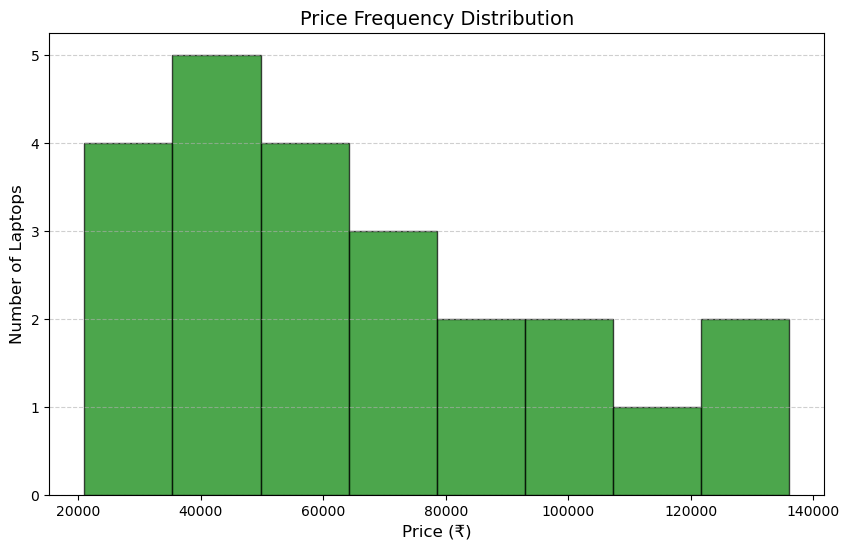

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df['Price_Numeric'], bins=8, color='green', edgecolor='black', alpha=0.7)

plt.title('Price Frequency Distribution', fontsize=14)
plt.xlabel('Price (₹)', fontsize=12)
plt.ylabel('Number of Laptops', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.savefig("HP_Price_Histogram.png")
plt.show()

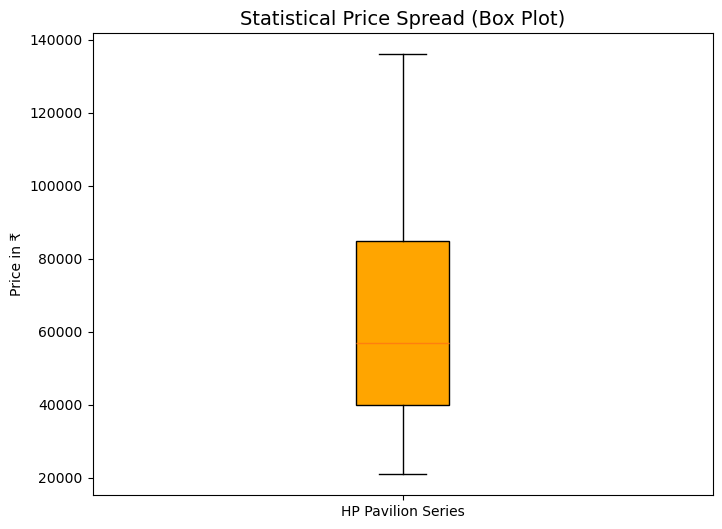

In [13]:
plt.figure(figsize=(8, 6))
plt.boxplot(
    df['Price_Numeric'],
    patch_artist=True,
    boxprops=dict(facecolor="orange")
)

plt.title('Statistical Price Spread (Box Plot)', fontsize=14)
plt.ylabel('Price in ₹')
plt.xticks([1], ['HP Pavilion Series'])

plt.savefig("HP_Price_Boxplot.png")
plt.show()

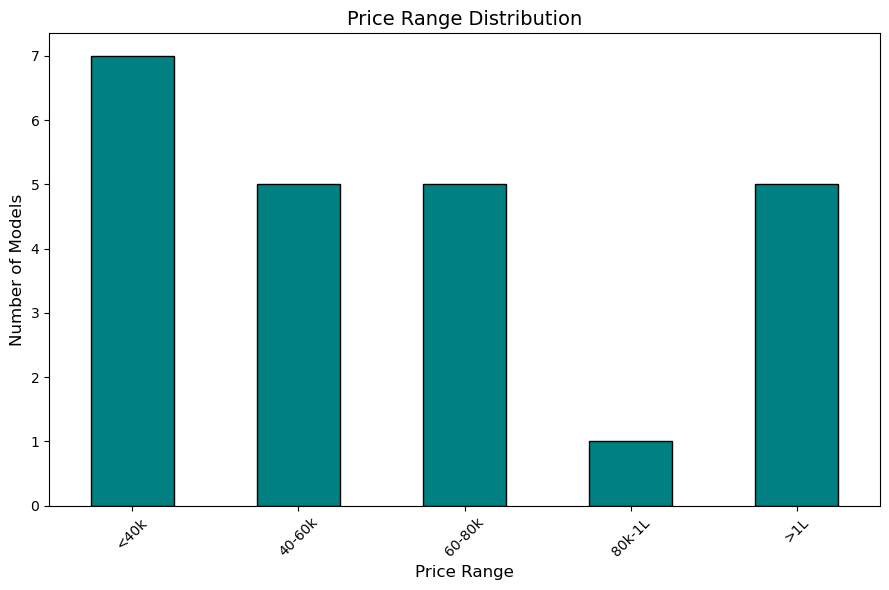

In [14]:
bins = [0, 40000, 60000, 80000, 100000, 150000]
labels = ['<40k', '40-60k', '60-80k', '80k-1L', '>1L']

df['Range'] = pd.cut(df['Price_Numeric'], bins=bins, labels=labels)

range_counts = df['Range'].value_counts().sort_index()

plt.figure(figsize=(9, 6))
range_counts.plot(kind='bar', color='teal', edgecolor='black')

plt.title('Price Range Distribution', fontsize=14)
plt.xlabel('Price Range', fontsize=12)
plt.ylabel('Number of Models', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("HP_Price_Range_Distribution.png")
plt.show()

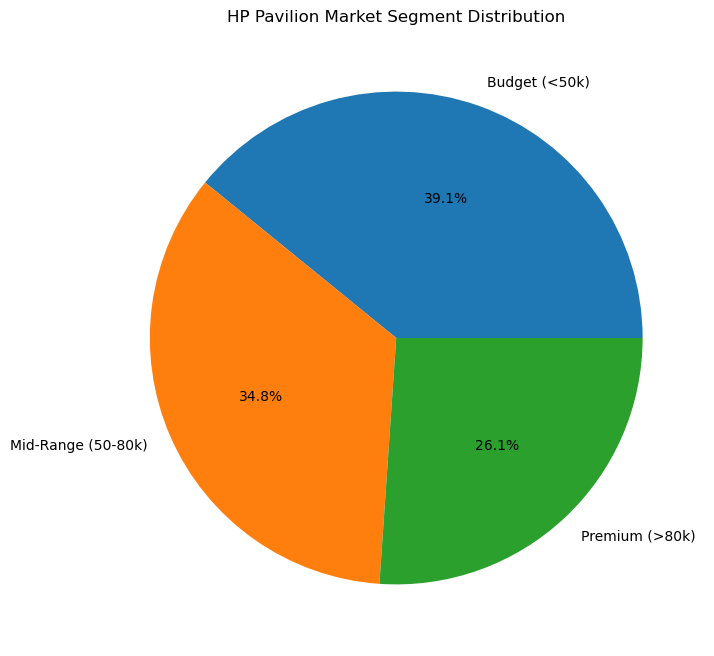

In [15]:
with open("Price_Comparison_Table.txt", "w", encoding="utf-8") as f:
    f.write("TOP 5 BUDGET MODELS\n")
    f.write(top_5_cheap.to_string(index=False))
    f.write("\n\nTOP 5 PREMIUM MODELS\n")
    f.write(top_5_costly.to_string(index=False))


bins = [0, 50000, 80000, 150000]
labels = ["Budget (<50k)", "Mid-Range (50-80k)", "Premium (>80k)"]

df["Category"] = pd.cut(df["Price_Numeric"], bins=bins, labels=labels)

cat_counts = df["Category"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(cat_counts, labels=cat_counts.index, autopct="%1.1f%%")
plt.title("HP Pavilion Market Segment Distribution")
plt.savefig("HP_Market_Pie_Chart.png")
plt.show()

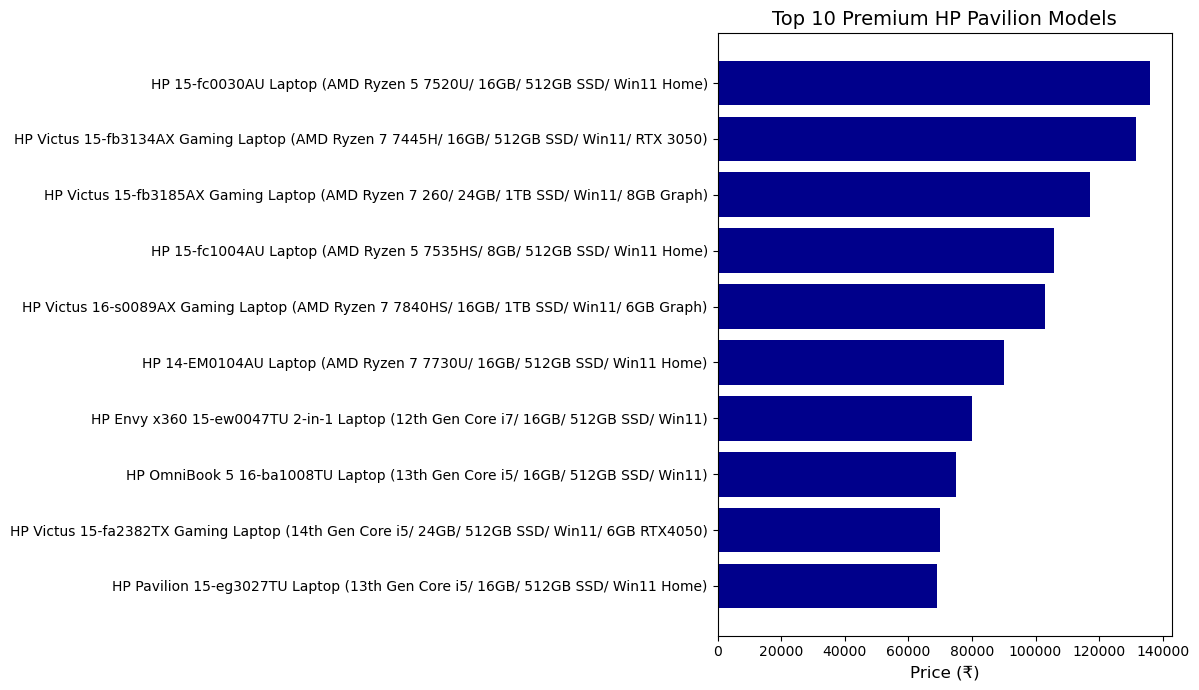

In [16]:
top_10 = df.sort_values('Price_Numeric', ascending=False).head(10)

plt.figure(figsize=(12, 7))
plt.barh(top_10['Laptop Model'], top_10['Price_Numeric'], color='darkblue')

plt.gca().invert_yaxis()

plt.title('Top 10 Premium HP Pavilion Models', fontsize=14)
plt.xlabel('Price (₹)', fontsize=12)

plt.tight_layout()
plt.savefig("HP_Top_10_Expensive.png")
plt.show()

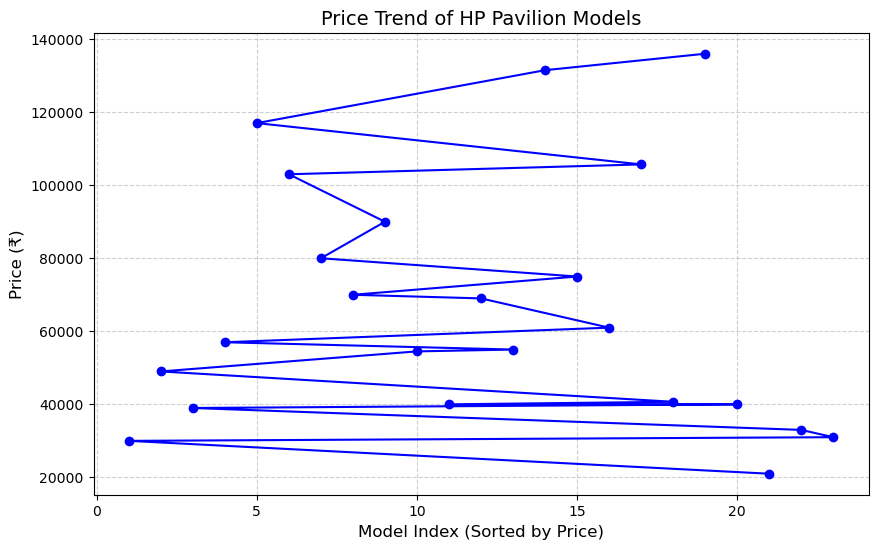

In [17]:
sorted_df = df.sort_values('Price_Numeric')

plt.figure(figsize=(10, 6))
plt.plot(sorted_df['Price_Numeric'], marker='o', linestyle='-', color='blue')

plt.title('Price Trend of HP Pavilion Models', fontsize=14)
plt.xlabel('Model Index (Sorted by Price)', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig("HP_Price_Trend_Line.png")
plt.show()

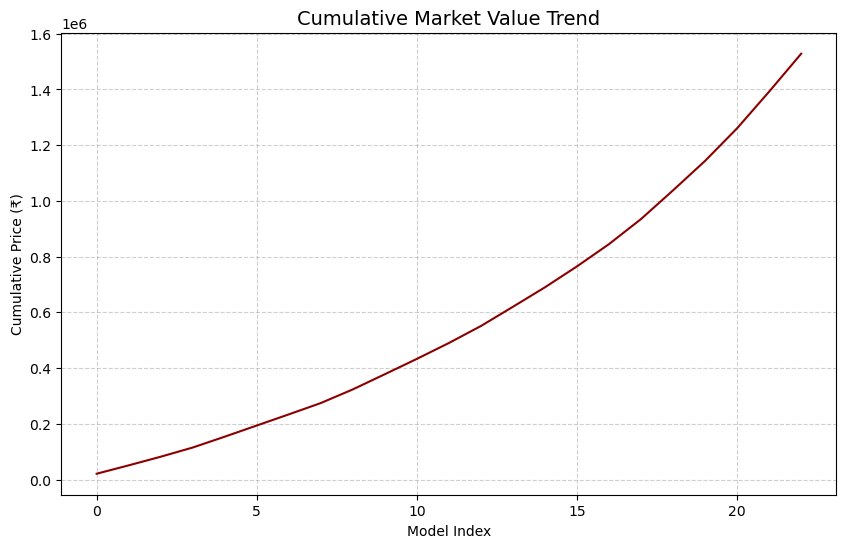

In [18]:
sorted_prices = sorted_df['Price_Numeric'].reset_index(drop=True)
cumulative = sorted_prices.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(cumulative, color='darkred')

plt.title('Cumulative Market Value Trend', fontsize=14)
plt.xlabel('Model Index')
plt.ylabel('Cumulative Price (₹)')

plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig("HP_Cumulative_Price.png")
plt.show()

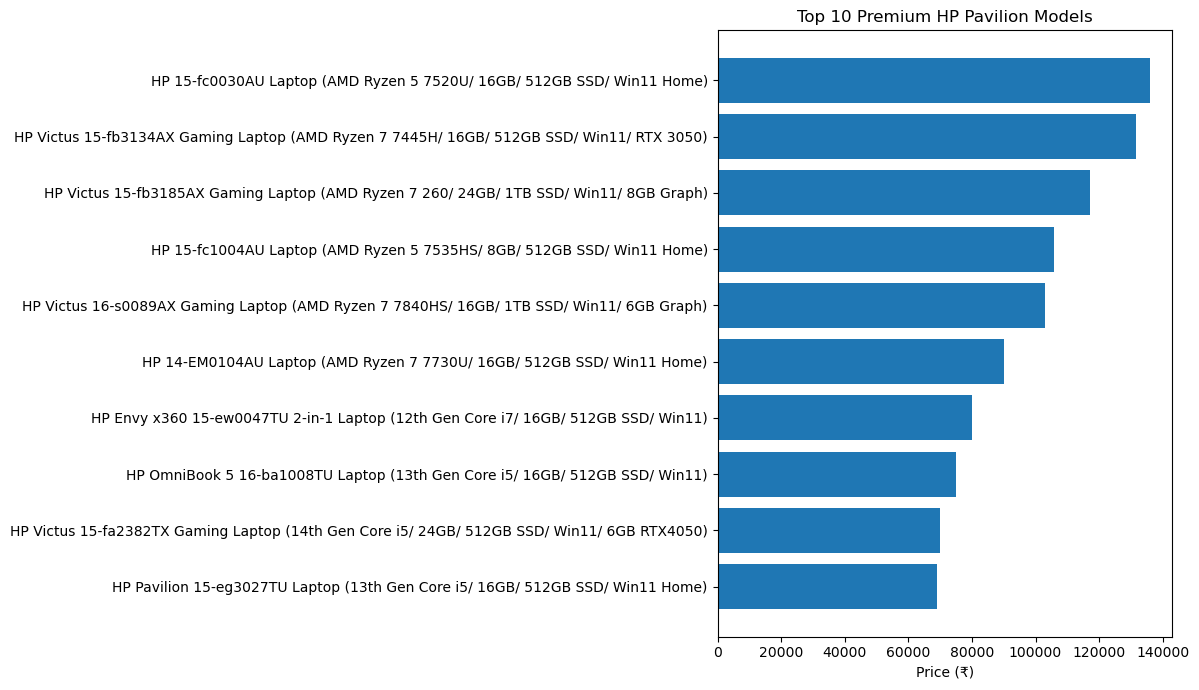

Top 10 chart saved as 'HP_Top_10_Expensive.png'


In [19]:
# Sort by numeric price
top_10 = df.sort_values("Price_Numeric", ascending=False).head(10)

plt.figure(figsize=(12, 7))
plt.barh(top_10["Laptop Model"], top_10["Price_Numeric"])

plt.gca().invert_yaxis()
plt.title("Top 10 Premium HP Pavilion Models")
plt.xlabel("Price (₹)")

plt.tight_layout()
plt.savefig("HP_Top_10_Expensive.png")
plt.show()

print("Top 10 chart saved as 'HP_Top_10_Expensive.png'")

In [20]:
df.to_csv("hp_pavilion_price_comparison.csv", index=False)
plt.savefig("HP_Price_Analysis_Chart.png")

<Figure size 640x480 with 0 Axes>

In [21]:
import os
print(os.getcwd())

C:\Users\Dell
